In [18]:
import sys
sys.path.append('../testing')

from TC import TC


import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [19]:
CATEGORICAL_FILE = r"../data/drug_consumption_transformed.csv"

PRED_CAT_FILE = r"../data/knn/pred_cat.csv"
PRED_NUM_FILE = r"../data/knn/pred_num.csv"

OUTPUT_CAT_PLOT = r"../plots/knn_TC_cat.png"
OUTPUT_NUM_PLOT = r"../plots/knn_TC_num.png"

In [20]:
df_cat = pd.read_csv(CATEGORICAL_FILE)
true_values = df_cat["choc"].values

n = len(true_values)
KS = range(1, n, 1)[9::10] # only use every 10th value of K (10, 20, 30, ...)
pred_cat = np.loadtxt(PRED_CAT_FILE, delimiter = ",", dtype = "object")[9::10]
pred_num = np.loadtxt(PRED_NUM_FILE, delimiter = ",", dtype = "object")[9::10]



In [21]:
confusion_cat = np.apply_along_axis(lambda pred: confusion_matrix(true_values, pred).T, 1, pred_cat)
confusion_num = np.apply_along_axis(lambda pred: confusion_matrix(true_values, pred).T, 1, pred_num)

TC_cat = np.array([TC(C) for C in confusion_cat])
TC_num = np.array([TC(C) for C in confusion_num])

In [22]:
min_TC_cat = TC_cat.min()
min_index_cat = np.argmin(TC_cat)
min_K_cat = KS[min_index_cat]

min_TC_num = TC_num.min()
min_index_num = np.argmin(TC_num)
min_K_num = KS[min_index_num]

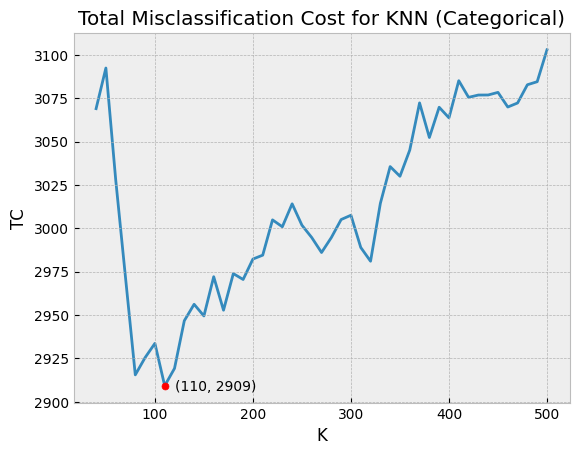

In [23]:
plt.style.use("bmh")
plt.plot(KS[3:50], TC_cat[3:50], zorder = 0)
plt.xlabel("K")
plt.ylabel("TC")
plt.title("Total Misclassification Cost for KNN (Categorical)")
plt.scatter(min_K_cat, min_TC_cat, color = "red", zorder = 1, s = 25)
plt.annotate((min_K_cat, int(min_TC_cat)), xy=(min_K_cat, min_TC_cat), xytext=(min_K_cat+10, min_TC_cat-3))

plt.savefig(OUTPUT_CAT_PLOT, dpi = 300)
plt.show()

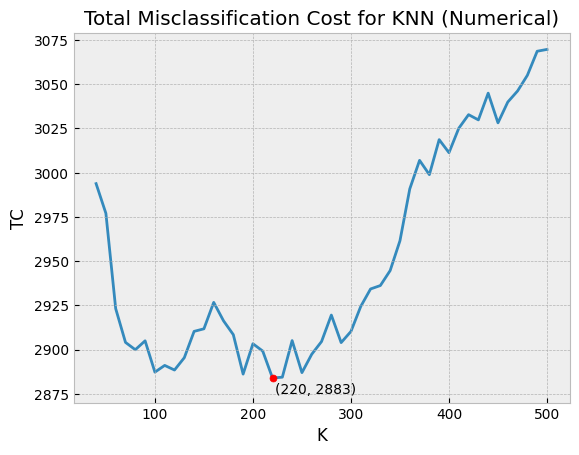

In [36]:
plt.style.use("bmh")
plt.plot(KS[3:50], TC_num[3:50], zorder = 0)
plt.xlabel("K")
plt.ylabel("TC")
plt.ylim(2870)
plt.title("Total Misclassification Cost for KNN (Numerical)")
plt.scatter(min_K_num, min_TC_num, color = "red", zorder = 1, s = 25)
plt.annotate((min_K_num, int(min_TC_num)), xy=(min_K_num, min_TC_num), xytext=(min_K_num+3, min_TC_num-9))


plt.savefig(OUTPUT_NUM_PLOT, dpi = 300)
plt.show()